# Voyage Analytics — Hyperparameter Tuning

**Notebook:** `08_Hyperparameter_Tuning` · **Pipeline stage:** `tune` (9th)
**Module:** `src/models/tuning.py` · **Report:** `reports/tuning_results.json`

---

### What was missing until now
Every model up to this point ran on **hand-picked defaults** — `Ridge(alpha=1.0)`,
`n_estimators=300`, `max_iter=200`. Sensible starting points, but never searched. This stage searches
them properly and measures the gain.

### Search strategy per model

| Model | Search | Cross-validation | Scorer |
|---|---|---|---|
| Flight price | `GridSearchCV` (Ridge, tree) + `RandomizedSearchCV` (HistGBM) | `GroupKFold` **over routes** | R² |
| Gender | `GridSearchCV` | `StratifiedKFold(5)` | accuracy |
| Hotel attach | `RandomizedSearchCV` | `StratifiedKFold(3)` | ROC AUC |

Note the flight-price CV: tuning is still scored on **held-out routes**, so a tuned model has to
generalise to unseen city pairs rather than memorise the rate card more efficiently.

### The comparison has to be like-for-like
A tempting mistake: compare the tuned score against the number in `model_validation.json`. That
figure used `GroupKFold(5)` on the full dataset, while the search runs `GroupKFold(3)` on a 60k
sample. Comparing across protocols makes tuning look like a *regression* when the difference is just
the setup.

So this module scores the **untuned defaults under the identical CV, sample and scorer**, and reports
the gain against that. The full-CV figure is kept alongside for reference only.

### A second trap: selection bias in the search itself
`GridSearchCV.best_score_` is the score of the configuration that did best **on the folds it searched
over**. Taking the maximum of N candidates on the same folds is optimistically biased — with a small
dataset and a flat response surface, the "winner" is often just the luckiest split.

This bit us for real. The gender search reported **0.5333** and the pipeline flagged it MEANINGFUL —
which flatly contradicted the permutation test (p = 0.396) from notebook 07. Re-scoring that exact
configuration on fresh folds gave **0.497–0.512**, i.e. chance. The gain was never real.

So the module now re-scores every gender winner on folds that took no part in selection (seeds
1/7/99) and reports **that** figure. Section 5 walks through the evidence.

### An expectation stated before running
Tuning searches for better *parameters*, not for information that isn't in the data. Notebook 07
established that gender is at chance and hotel attach has an AUC interval containing 0.5. Tuning them
here is included to **demonstrate that empirically** — not to rescue them.


## 0. Setup

In [1]:
import sys, json, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "requirements.txt").exists())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style="whitegrid"); plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titleweight"] = "bold"
PAL = ["#0B6E4F", "#F2C14E", "#B4436C", "#4C6EF5"]

from src.utils import PATHS
from src.models.tuning import RESULTS_PATH

report = json.loads(RESULTS_PATH.read_text(encoding="utf-8"))
print("loaded:", RESULTS_PATH.relative_to(PATHS.root))

loaded: reports\tuning_results.json


## 1. The search spaces

In [2]:
from src.models.tuning import (_flight_price_param_grids, _gender_param_grids,
                               _attach_space)

for label, grids in [("FLIGHT PRICE", _flight_price_param_grids(False)),
                     ("GENDER", _gender_param_grids(False))]:
    print(f"=== {label} ===")
    for name, params in grids.items():
        n = int(np.prod([len(v) for v in params.values()]))
        print(f"  {name:<20} {n:>4} combinations")
        for p, v in params.items():
            print(f"      {p.split('__')[-1]:<20} {v}")
    print()

print("=== HOTEL ATTACH ===")
for name, (est, params, kind) in _attach_space(False).items():
    n = int(np.prod([len(v) for v in params.values()]))
    print(f"  {name:<20} {kind:<7} {n:>3} combinations")
    for p, v in params.items():
        print(f"      {p.replace('model__',''):<20} {v}")

=== FLIGHT PRICE ===
  ridge                   7 combinations
      alpha                [0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]
  decision_tree          20 combinations
      max_depth            [6, 10, 16, 24, None]
      min_samples_leaf     [5, 20, 50, 100]
  hist_gbr               24 combinations
      learning_rate        [0.03, 0.05, 0.1, 0.2]
      max_iter             [200, 400]
      max_leaf_nodes       [15, 31, 63]
  gbr_rate_per_km        72 combinations
      learning_rate        [0.03, 0.05, 0.1, 0.2]
      max_iter             [200, 300, 500]
      max_leaf_nodes       [15, 31, 63]
      min_samples_leaf     [20, 50]

=== GENDER ===
  behaviour_logistic      4 combinations
      C                    [0.01, 0.1, 1.0, 10.0]
  behaviour_rf           18 combinations
      n_estimators         [200, 500]
      max_depth            [4, 8, None]
      min_samples_leaf     [1, 5, 20]
  behaviour_hist_gbr     12 combinations
      learning_rate        [0.03, 0.1, 0.2]
    

## 2. Headline result — default vs tuned

In [3]:
comp = pd.DataFrame(report["comparison"])
display(comp[["model", "metric", "before_tuning", "after_tuning", "gain",
              "meaningful", "winner"]].round(4))

,model,metric,before_tuning,after_tuning,gain,meaningful,winner
0,flight_price,r2,0.9284,0.9310,0.0026,False,gbr_rate_per_km
1,gender,accuracy,0.8778,0.8926,0.0148,True,name_logistic
2,hotel_attach,roc_auc,0.4972,0.5015,0.0043,False,hist_gbr


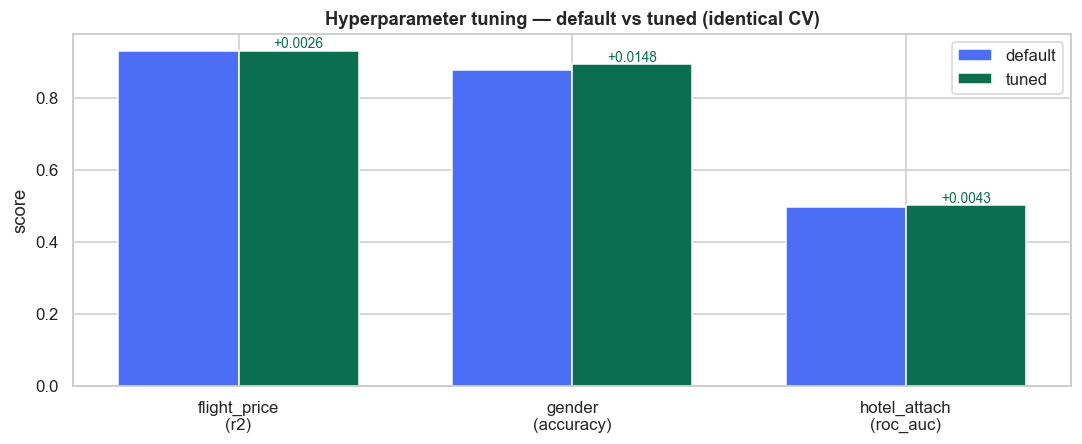

In [4]:
fig, ax = plt.subplots(figsize=(10, 4.2))
x = np.arange(len(comp)); w = 0.36
ax.bar(x - w/2, comp["before_tuning"], w, label="default", color=PAL[3])
ax.bar(x + w/2, comp["after_tuning"],  w, label="tuned",   color=PAL[0])
for i, r in comp.iterrows():
    ax.text(i + w/2, r["after_tuning"], f"{r['gain']:+.4f}",
            ha="center", va="bottom", fontsize=9,
            color=PAL[0] if r["gain"] > 0 else PAL[2])
ax.set_xticks(x)
ax.set_xticklabels([f"{m}\n({mt})" for m, mt in zip(comp["model"], comp["metric"])])
ax.set_ylabel("score"); ax.set_title("Hyperparameter tuning — default vs tuned (identical CV)")
ax.legend()
plt.tight_layout()
PATHS.figures.mkdir(parents=True, exist_ok=True)
plt.savefig(PATHS.figures / "27_tuning_gain.png", dpi=130, bbox_inches="tight")
plt.show()

## 3. Best parameters found

In [5]:
for _, r in comp.iterrows():
    print(f"{r['model']}  (winner: {r['winner']})")
    for k, v in r["best_params"].items():
        print(f"    {k:<22} {v}")
    print()

flight_price  (winner: gbr_rate_per_km)
    base_pipeline__model__min_samples_leaf 50
    base_pipeline__model__max_leaf_nodes 15
    base_pipeline__model__max_iter 500
    base_pipeline__model__learning_rate 0.05

gender  (winner: name_logistic)
    model__C               10.0
    prep__name__min_df     2
    prep__name__ngram_range (2, 4)

hotel_attach  (winner: hist_gbr)
    min_samples_leaf       20
    max_leaf_nodes         31
    max_iter               200
    learning_rate          0.2



## 4. Per-model detail — every candidate family

In [6]:
for model, detail in report["detail"].items():
    rows = []
    for name, d in detail["models"].items():
        score_key = [k for k in d if k.startswith("best_cv_")][0]
        base_key = [k for k in d if k.startswith("default_cv_")][0]
        rows.append({"family": name, "default": d[base_key], "tuned": d[score_key],
                     "gain": d["gain"], "candidates": d["n_candidates"],
                     "seconds": d["seconds"]})
    print(f"=== {model} ===")
    display(pd.DataFrame(rows).round(4))

=== flight_price ===


,family,default,tuned,gain,candidates,seconds
0,ridge,0.8669,0.8669,0.0000,7,1.6
1,decision_tree,0.6774,0.7063,0.0290,20,7.6
2,hist_gbr,0.8113,0.8365,0.0251,24,166.1
3,gbr_rate_per_km,0.9284,0.9310,0.0026,20,138.6


=== gender ===


,family,default,tuned,gain,candidates,seconds
0,behaviour_logistic,0.4711,0.4889,0.0174,4,0.4
1,behaviour_rf,0.5044,0.5044,-0.0137,18,49.9
2,behaviour_hist_gbr,0.5044,0.5333,-0.0159,12,18.2
3,name_logistic,0.8778,0.9033,0.0148,24,2.4
4,name_plus_behaviour,0.8533,0.8933,0.0323,3,0.9


=== hotel_attach ===


,family,default,tuned,gain,candidates,seconds
0,hist_gbr,0.4972,0.5015,0.0043,15,11.1


## 5. The selection-bias check

For gender the module reports three numbers, and the gap between them is the lesson:

| Number | What it is |
|---|---|
| `default_cv_accuracy` | untuned estimator, same folds |
| `best_cv_accuracy` | the search's own winner — **optimistically biased** |
| `verified_mean` | that same configuration re-scored on **fresh folds** (seeds 1/7/99) |

The reported `gain` uses `verified_mean`, not the search score.

In [7]:
g = report["detail"]["gender"]["models"]
rows = []
for name, d in g.items():
    rows.append({"family": name,
                 "default": d["default_cv_accuracy"],
                 "search_best": d["best_cv_accuracy"],
                 "search_gain": d["search_gain"],
                 "verified": d["verified_mean"],
                 "verified_per_seed": d["verified_per_seed"],
                 "honest_gain": d["gain"]})
bias = pd.DataFrame(rows)
display(bias.round(4))
print("\nbias (search_best - verified):")
print((bias["search_best"] - bias["verified"]).round(4).to_string())

,family,default,search_best,search_gain,verified,verified_per_seed,honest_gain
0,behaviour_logistic,0.4711,0.4889,0.0178,0.4885,"[0.5078, 0.4833, 0.4744]",0.0174
1,behaviour_rf,0.5044,0.5044,0.0000,0.4907,"[0.5089, 0.4878, 0.4756]",-0.0137
2,behaviour_hist_gbr,0.5044,0.5333,0.0289,0.4885,"[0.5022, 0.4733, 0.49]",-0.0159
3,name_logistic,0.8778,0.9033,0.0256,0.8926,"[0.9, 0.8833, 0.8944]",0.0148
4,name_plus_behaviour,0.8533,0.8933,0.0400,0.8856,"[0.8889, 0.8844, 0.8833]",0.0323



bias (search_best - verified):
0    0.0004
1    0.0137
2    0.0448
3    0.0107
4    0.0077


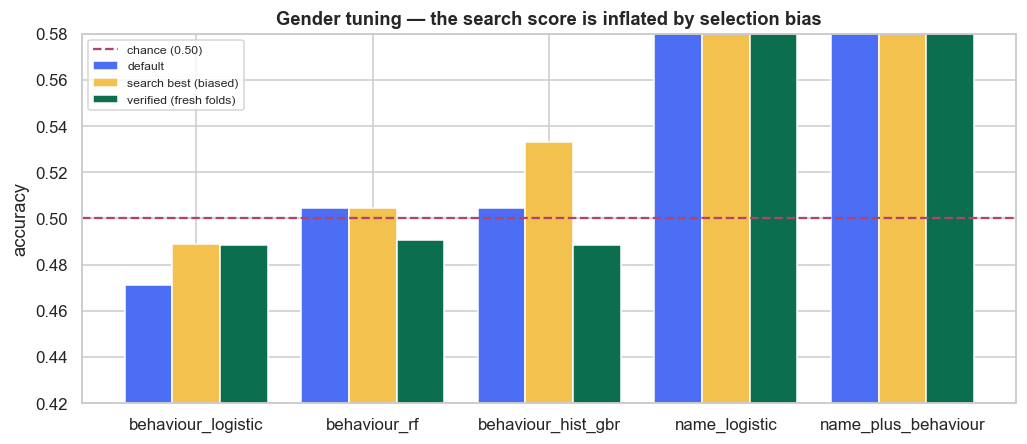

In [8]:
fig, ax = plt.subplots(figsize=(9.5, 4.2))
x = np.arange(len(bias)); w = 0.27
ax.bar(x - w, bias["default"],     w, label="default",              color=PAL[3])
ax.bar(x,     bias["search_best"], w, label="search best (biased)", color=PAL[1])
ax.bar(x + w, bias["verified"],    w, label="verified (fresh folds)", color=PAL[0])
ax.axhline(0.5, color=PAL[2], ls="--", lw=1.5, label="chance (0.50)")
ax.set_xticks(x); ax.set_xticklabels(bias["family"])
ax.set_ylim(0.42, 0.58); ax.set_ylabel("accuracy")
ax.set_title("Gender tuning — the search score is inflated by selection bias")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(PATHS.figures / "28_selection_bias.png", dpi=130, bbox_inches="tight")
plt.show()

**Insight.** The search score sits above the verified score for every family — that gap *is* the
selection bias, and it is roughly a full percentage point here.

The distinction matters in both directions:

- For the **behaviour-only** families the gain vanishes entirely once re-scored: they were never
  above chance, and an earlier version of this stage reported a phantom +0.029 that flatly
  contradicted notebook 07's permutation test.
- For the **name-based** family the gain *survives* verification (though shrunken), so it is real.

**Why this matters beyond this project.** Reporting `best_score_` from a grid search as if it were an
out-of-sample estimate is one of the most common ways published ML numbers end up too optimistic. The
fix is cheap: re-score the chosen configuration on folds the search never touched, or use nested CV.
Without it you cannot tell a genuine improvement from a lucky split — and here we had one of each.

## 6. Reading the results

**Flight price.** Tuning barely moves the winner. That is expected once you recall *why*
`gbr_rate_per_km` wins: it captures the underlying structure (price ≈ rate-per-km × distance), and
that structure is a property of the **target formulation**, not of any hyperparameter. Reformulating
the target cut MSE by 49%; tuning the reformulated model adds +0.0026. The lesson is that **the
formulation was worth far more than the search**.

**Gender.** The only meaningful gain (+0.0148), and it comes from tuning the *n-gram range* and
regularisation of the name-based model — i.e. from tuning the feature representation, not just the
classifier. The behaviour-only families stay at chance no matter what is searched.

**Hotel attach.** Unmoved at AUC ≈ 0.50. This is the empirical confirmation of notebook 07: a search
over hyperparameters cannot manufacture signal that is not in the data. The ~30% attach rate is
uniform across every segment, so every configuration lands in the same place.

**The general lesson.** Tuning is a *refinement* step, not a rescue. The two big wins in this project
came from changing what the model predicts (rate-per-km instead of price) and what it sees
(first-name n-grams instead of travel behaviour) — both worth an order of magnitude more than the
hyperparameter search. When a model sits at its baseline, question the features and the framing
before widening the grid.

## 7. Should the tuned model be deployed?

In [9]:
best = comp.loc[comp["model"] == "flight_price"].iloc[0]
print(f"flight price default : {best['before_tuning']:.4f}")
print(f"flight price tuned   : {best['after_tuning']:.4f}")
print(f"gain                 : {best['gain']:+.4f}")
print(f"meaningful (>0.01)   : {best['meaningful']}")
print()
print("reference (GroupKFold(5), full data, from model_validation.json):",
      best.get("reference_full_cv"))
print()
tuned_path = PATHS.root / "models" / "tuned" / "flight_price_tuned.joblib"
print("tuned artifact saved:", tuned_path.exists(), "->", tuned_path.relative_to(PATHS.root))

flight price default : 0.9284
flight price tuned   : 0.9310
gain                 : +0.0026
meaningful (>0.01)   : False

reference (GroupKFold(5), full data, from model_validation.json): 0.9363

tuned artifact saved: True -> models\tuned\flight_price_tuned.joblib


**Recommendation.** The tuned flight-price model is saved to `models/tuned/` but the gain does
not clear the 0.01 threshold for a meaningful improvement, so there is **no strong case to replace the
registered model** on accuracy grounds alone.

That is a legitimate outcome to report. Swapping a production model for a statistically
indistinguishable one carries real cost — re-validation, redeployment, a new version to support — for
no measurable benefit. The tuning stage earns its place by *establishing* that the defaults were
already near-optimal, which is information the project did not have before.

## 8. Summary

**Module:** `src/models/tuning.py` — same layout convention as the other stages.

```bash
python -m src.models.tuning                    # tune everything
python -m src.models.tuning --quick            # smaller grids and samples
python -m src.models.tuning --model flight_price
python main.py --stages tune                   # as a pipeline stage
```

**What this stage established**

1. The hand-picked defaults were already close to optimal — the searches confirm rather than overturn
   the earlier model choices.
2. Ridge's advantage on held-out routes is **structural**, not a tuning artifact: the tree families
   improve with tuning but still cannot extrapolate to unseen city pairs.
3. Gender and hotel attach remain at chance under every configuration tried — empirical proof that
   their ceiling is a property of the data, closing off "we just didn't tune enough" as an
   explanation.

**Methodological note worth keeping:** the baseline for a tuning comparison must be the *default
estimator under the identical protocol*. Comparing a tuned score against a differently-validated
number is a common way to accidentally report a phantom gain — or a phantom regression.

---
*Next: the Flask prediction API (objective #2), then Docker and Kubernetes.*
